# Notebook 05 - Modeling Digital Burnout Prediction

Xây dựng mô hình học máy nhằm dự đoán mức độ Digital Burnout của sinh viên dựa trên bộ đặc trưng đã được xác thực từ quá trình Feature Validation.

Quy trình thực hiện gồm các bước chính:

1. Chuẩn bị dữ liệu đầu vào:
    - Load dataset đã làm sạch.
    - Load validated features.
    - Xây dựng Feature Matrix và Target Variable.
    - Chia dữ liệu thành tập huấn luyện, validation và test.
    - Xây dựng preprocessing pipeline.

2. Huấn luyện mô hình:
    - Xây dựng baseline model.
    - Huấn luyện các mô hình Machine Learning chính.
    - Xây dựng các mô hình Ensemble.

3. Đánh giá mô hình:
    - So sánh hiệu suất giữa các mô hình.
    - Phân tích Confusion Matrix.
    - Đánh giá ROC Curve.
    - Lựa chọn mô hình tốt nhất.

4. Xuất kết quả:
    - Lưu mô hình tốt nhất.
    - Lưu bảng đánh giá mô hình.
    - Lưu các kết quả phục vụ phân tích tiếp theo.


# 0. Set Up

Thiết lập môi trường làm việc, import thư viện cần thiết và cấu hình hiển thị phục vụ quá trình xây dựng mô hình học máy.

In [102]:
# Import thư viện xử lý dữ liệu

import os
import numpy as np
import pandas as pd

# Import thư viện trực quan hóa dữ liệu

import matplotlib.pyplot as plt
import seaborn as sns

# Import thư viện Machine Learning

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder


from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier,
    StackingClassifier
)

from xgboost import XGBClassifier

# Import thư viện đánh giá mô hình

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

# Import thư viện lưu mô hình

import joblib

# Thiết lập cấu hình hiển thị

pd.set_option(
    "display.max_columns",
    None
)
pd.set_option(
    "display.max_rows",
    100
)


# Khai báo random state

random_state = 42

print("Đã thiết lập môi trường Modeling.")

Đã thiết lập môi trường Modeling.


# 1. Data Preparation

Chuẩn bị dữ liệu đầu vào phục vụ quá trình xây dựng mô hình dự đoán Digital Burnout.

Phần này thực hiện các bước:

- Đọc dataset đã được làm sạch từ quá trình Data Cleaning.
- Load danh sách feature đã được xác thực từ Notebook 04.
- Xác định Feature Matrix và Target Variable.
- Chia dữ liệu thành tập huấn luyện, validation và test.
- Xây dựng pipeline tiền xử lý phù hợp với đặc điểm dữ liệu.

Việc tách riêng quá trình chuẩn bị dữ liệu giúp đảm bảo tính nhất quán giữa các bước Feature Validation và Modeling.

## 1.1 Load Cleaned Dataset

Đọc dataset đã được xử lý và chuẩn hóa từ bước Data Cleaning để sử dụng trong quá trình xây dựng mô hình.

Dataset được sử dụng là phiên bản đã làm sạch:

- Xử lý missing values.
- Chuẩn hóa kiểu dữ liệu.
- Xây dựng các chỉ số Digital Burnout.
- Tạo biến mục tiêu `dbi_level`.

Dataset này là đầu vào chính cho quá trình Modeling.

In [103]:
# Khai báo đường dẫn dataset đã được xử lý

data_path = (
    "../../data/processed/vietnam_dataset/"
    "vn_digital_burnout_cleaned.csv"
)

# Đọc dataset

survey_dataset = pd.read_csv(
    data_path,
    encoding="utf-8-sig"
)

# Kiểm tra thông tin dataset

print("Đã tải dataset thành công.")
print(f"Số lượng quan sát: {survey_dataset.shape[0]:,}")
print(f"Số lượng biến: {survey_dataset.shape[1]:,}")

Đã tải dataset thành công.
Số lượng quan sát: 654
Số lượng biến: 30


## 1.2 Load Validated Features

Đọc danh sách các đặc trưng đã được xác thực từ Notebook 04 để sử dụng làm biến đầu vào cho quá trình xây dựng mô hình dự đoán Digital Burnout.

Trong quá trình Feature Validation, các feature đã được đánh giá thông qua:

- ANOVA F-test.
- Random Forest Feature Importance.
- So sánh mức độ ổn định giữa phương pháp thống kê và phương pháp học máy.

Các kết quả Feature Validation được sử dụng để xác nhận tính hợp lý của bộ chỉ số Digital Burnout, không đồng nghĩa toàn bộ các feature được chọn sẽ được sử dụng làm biến đầu vào cho mô hình dự đoán. Các biến cấu thành trực tiếp Digital Burnout Score được loại khỏi giai đoạn Modeling nhằm tránh hiện tượng target leakage. Vì vậy, Notebook 05 chỉ sử dụng các đặc trưng hành vi và bối cảnh có khả năng dự báo burnout nhưng không trực tiếp tham gia xây dựng nhãn mục tiêu.

In [104]:
# Khai báo đường dẫn file validated features

validated_features_path = (
    "../../data/processed/vietnam_dataset/"
    "validated_features.csv"
)

# Đọc danh sách feature đã được xác thực

validated_features = pd.read_csv(
    validated_features_path,
    encoding="utf-8-sig"
)

# Trích xuất danh sách feature

validated_feature_list = (
    validated_features["Feature"]
    .tolist()
)

# Kiểm tra thông tin validated features

print("Đã tải danh sách feature được xác thực.")
print(
    f"Số lượng feature được sử dụng: {len(validated_feature_list)}"
)

display(
    validated_features
)

Đã tải danh sách feature được xác thực.
Số lượng feature được sử dụng: 10


,Feature
0,motivation_level
1,loss_of_interest
2,digital_exhaustion
3,emotional_exhaustion
4,notification_count
5,performance_decline
6,physical_fatigue
7,sleep_quality
8,digital_stress
9,doomscrolling_duration


In [105]:
# Kiểm tra các feature đã xác thực có tồn tại trong dataset

missing_features = [
    feature
    for feature in validated_feature_list
    if feature not in survey_dataset.columns
]

print(
    f"Số lượng feature không tồn tại: {len(missing_features)}"
)

display(
    pd.DataFrame({
        "Missing Feature": missing_features
    })
)

Số lượng feature không tồn tại: 0


,Missing Feature


## 1.3 Define Feature Matrix and Target

Xác định tập đặc trưng đầu vào và biến mục tiêu phục vụ quá trình xây dựng mô hình dự đoán Digital Burnout.

Để tránh hiện tượng data leakage, các biến được sử dụng làm đầu vào mô hình chỉ bao gồm những yếu tố có khả năng dự báo Digital Burnout từ hành vi sử dụng thiết bị, khả năng tập trung và mức độ phục hồi.

Các biến triệu chứng burnout trực tiếp được loại bỏ khỏi Feature Matrix vì chúng được sử dụng trong quá trình xây dựng Digital Burnout Score và có quan hệ trực tiếp với target.

In [106]:
# Xác định predictive features sử dụng cho mô hình

predictive_features = [

    # Digital Exposure Indicators

    "daily_screen_time",
    "social_media_hours",
    "doomscrolling_duration",
    "late_night_device_usage",
    "notification_count",
    "smartphone_unlocks",
    "app_switch_frequency",

    # Cognitive Performance Indicators

    "concentration_score",
    "distraction_frequency",
    "focus_sessions",
    "deep_work_hours",
    "task_completion_rate",
    "motivation_level",

    # Sleep and Recovery Indicators

    "sleep_hours",
    "sleep_quality"

]

# Xác định feature matrix

X = survey_dataset[
    predictive_features
]

# Xác định target

y = survey_dataset[
    "dbi_level_encoded"
]

print(
    "Đã xác định feature matrix và target."
)

print(
    f"Số lượng features: {X.shape[1]}"
)

print(
    f"Số lượng target classes: {y.nunique()}"
)

Đã xác định feature matrix và target.
Số lượng features: 15
Số lượng target classes: 3


## 1.4 Train / Validation / Test Split

Chia dataset thành ba tập dữ liệu độc lập nhằm phục vụ quá trình huấn luyện, lựa chọn và đánh giá mô hình Machine Learning.

Dataset được chia theo tỷ lệ:

- Training set - 70%: Sử dụng để huấn luyện mô hình.
- Validation set - 15%: Sử dụng để so sánh hiệu suất giữa các mô hình trong quá trình lựa chọn.
- Test set - 15%: Sử dụng để đánh giá hiệu quả cuối cùng của mô hình tốt nhất.

Phương pháp stratified splitting được áp dụng nhằm đảm bảo tỷ lệ các lớp Digital Burnout (`dbi_level`) được duy trì tương đồng giữa các tập dữ liệu.

Việc phân chia dữ liệu độc lập giúp hạn chế hiện tượng overfitting và đảm bảo đánh giá khách quan khả năng tổng quát hóa của mô hình.

In [107]:
# Chia dữ liệu thành tập train và tập tạm thời

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=random_state,
    stratify=y
)

# Chia tập tạm thời thành validation và test

X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=random_state,
    stratify=y_temp
)

# Kiểm tra kích thước các tập dữ liệu

print("Đã hoàn thành phân chia dữ liệu.")
print(f"Training set: {X_train.shape[0]:,} mẫu")
print(f"Validation set: {X_validation.shape[0]:,} mẫu")
print(f"Test set: {X_test.shape[0]:,} mẫu")

Đã hoàn thành phân chia dữ liệu.
Training set: 457 mẫu
Validation set: 98 mẫu
Test set: 99 mẫu


In [108]:
# Kiểm tra tỷ lệ phân bố Digital Burnout Level giữa các tập

split_distribution = pd.DataFrame({
    "Train": y_train.value_counts(normalize=True),
    "Validation": y_validation.value_counts(normalize=True),
    "Test": y_test.value_counts(normalize=True)
})


split_distribution = (
    split_distribution * 100
).round(2)


display(
    split_distribution
)

,Train,Validation,Test
dbi_level_encoded,,,
1,68.05,68.37,67.68
2,22.54,22.45,22.22
0,9.41,9.18,10.10


In [109]:
# Khai báo đường dẫn lưu validation dataset

validation_output_path = (
    "../../models/vietnam_dataset/"
)

# Lưu validation feature

joblib.dump(
    X_validation,
    f"{validation_output_path}X_validation.joblib"
)

# Lưu validation target

joblib.dump(
    y_validation,
    f"{validation_output_path}y_validation.joblib"
)

print("Đã lưu validation dataset.")

Đã lưu validation dataset.


## 1.5 Build Preprocessing Pipeline

Xây dựng quy trình tiền xử lý dữ liệu nhằm đảm bảo dữ liệu đầu vào được chuẩn hóa trước khi đưa vào các mô hình Machine Learning.

Pipeline tiền xử lý được xây dựng nhằm xử lý các nhóm biến khác nhau:

- Numerical Features:
    - Sử dụng StandardScaler để chuẩn hóa dữ liệu về cùng thang đo.
    - Giúp các mô hình học máy hoạt động ổn định hơn, đặc biệt với các mô hình dựa trên khoảng cách hoặc trọng số.

- Categorical Features:
    - Sử dụng OneHotEncoder để mã hóa biến phân loại.
    - Thiết lập `handle_unknown="ignore"` nhằm xử lý các giá trị mới chưa xuất hiện trong tập huấn luyện.

Dữ liệu sau khi xử lý sẽ được kết hợp với mô hình Machine Learning thông qua Pipeline, giúp tránh hiện tượng rò rỉ dữ liệu (data leakage) trong quá trình huấn luyện.

Do bộ validated features hiện tại chủ yếu bao gồm các biến số, quá trình tiền xử lý tập trung vào Numerical Scaling. Tuy nhiên, cấu trúc ColumnTransformer vẫn được duy trì để đảm bảo tính nhất quán với International Dataset và khả năng mở rộng trong tương lai.

In [110]:
# Xác định nhóm đặc trưng số và đặc trưng phân loại

numerical_features = (
    X_train.select_dtypes(
        include=["int64", "float64"]
    )
    .columns
    .tolist()
)

categorical_features = (
    X_train.select_dtypes(
        include=["object"]
    )
    .columns
    .tolist()
)

# Kiểm tra số lượng đặc trưng

print(
    f"Số lượng numerical features: {len(numerical_features)}"
)

print(
    f"Số lượng categorical features: {len(categorical_features)}"
)

Số lượng numerical features: 15
Số lượng categorical features: 0


In [111]:
# Pipeline xử lý đặc trưng số

numerical_pipeline = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# Pipeline xử lý đặc trưng phân loại

categorical_pipeline = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# Kết hợp hai pipeline

preprocessing_pipeline = ColumnTransformer(

    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

print(
    "Đã xây dựng Pipeline tiền xử lý."
)

display(

    pd.DataFrame({

        "Pipeline": [

            "Đặc trưng số",
            "Đặc trưng phân loại"

        ],

        "Phương pháp": [

            "StandardScaler",
            "OneHotEncoder"

        ]

    })

)

Đã xây dựng Pipeline tiền xử lý.


,Pipeline,Phương pháp
0,Đặc trưng số,StandardScaler
1,Đặc trưng phân loại,OneHotEncoder


# 2. Model Training

Xây dựng và huấn luyện các mô hình Machine Learning nhằm dự đoán mức độ Digital Burnout của sinh viên dựa trên bộ validated features đã được lựa chọn từ quá trình Feature Validation.

Phần này thực hiện quá trình xây dựng mô hình theo ba nhóm chính:

1. Baseline Model:
    - Sử dụng Logistic Regression làm mô hình cơ sở.
    - Được sử dụng để tạo mốc tham chiếu về hiệu suất dự đoán.

2. Primary Models:
    - Random Forest.
    - XGBoost.

    Các mô hình này được lựa chọn nhằm khai thác khả năng học các mối quan hệ phi tuyến giữa các đặc trưng hành vi và mức độ Digital Burnout.

3. Hybrid Models:
    - Voting Classifier.
    - Stacking Classifier.

    Các mô hình Ensemble được xây dựng nhằm kết hợp ưu điểm của nhiều mô hình riêng lẻ và cải thiện khả năng tổng quát hóa.

## 2.1 Model Selection

Xác định danh sách các mô hình Machine Learning được sử dụng trong quá trình dự đoán Digital Burnout.

Các mô hình được lựa chọn dựa trên khả năng xử lý bài toán phân loại đa lớp và mức độ phổ biến trong các nghiên cứu dự đoán dựa trên dữ liệu hành vi.

Các nhóm mô hình bao gồm:

### Baseline Model

**Logistic Regression**

- Được sử dụng làm mô hình cơ sở.
- Cung cấp mức hiệu suất tham chiếu ban đầu.
- Có khả năng giải thích tốt thông qua trọng số của các biến đầu vào.

### Primary Models

**Random Forest**

- Mô hình Ensemble dựa trên nhiều Decision Tree.
- Có khả năng học các mối quan hệ phi tuyến.
- Ít nhạy cảm với nhiễu trong dữ liệu.

**XGBoost**

- Thuật toán Gradient Boosting có hiệu suất cao.
- Có khả năng khai thác các mối quan hệ phức tạp giữa các đặc trưng.
- Được sử dụng rộng rãi trong các bài toán phân loại trên dữ liệu dạng bảng.

### Hybrid Models

**Voting Classifier**

- Kết hợp dự đoán từ Logistic Regression, Random Forest và XGBoost.
- Sử dụng cơ chế bỏ phiếu để đưa ra dự đoán cuối cùng.

**Stacking Classifier**

- Kết hợp nhiều mô hình cơ sở.
- Sử dụng Logistic Regression làm meta-model để học cách kết hợp các dự đoán đầu ra.

In [112]:
# Khai báo các mô hình Machine Learning

models = {

    "logistic_regression": LogisticRegression(
        max_iter=1000,
        random_state=random_state
    ),

    "random_forest": RandomForestClassifier(
        n_estimators=200,
        random_state=random_state
    ),

    "xgboost": XGBClassifier(
        random_state=random_state,
        eval_metric="mlogloss"
    )

}

# Kiểm tra danh sách mô hình

model_list = pd.DataFrame({

    "Model": [

        "Logistic Regression",
        "Random Forest",
        "XGBoost"

    ],

    "Category": [

        "Baseline Model",
        "Primary Model",
        "Primary Model"

    ]

})


display(
    model_list
)

,Model,Category
0,Logistic Regression,Baseline Model
1,Random Forest,Primary Model
2,XGBoost,Primary Model


In [113]:
# Khai báo Voting Classifier

voting_classifier = VotingClassifier(
    estimators=[
        (
            "logistic_regression",
            models["logistic_regression"]
        ),
        (
            "random_forest",
            models["random_forest"]
        ),
        (
            "xgboost",
            models["xgboost"]
        )
    ],
    voting="soft"
)


# Khai báo Stacking Classifier

stacking_classifier = StackingClassifier(
    estimators=[
        (
            "random_forest",
            models["random_forest"]
        ),
        (
            "xgboost",
            models["xgboost"]
        )
    ],

    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=random_state
    )
)

print(
    "Đã lựa chọn danh sách mô hình."
)

Đã lựa chọn danh sách mô hình.


## 2.2 Model Training Function

Xây dựng hàm huấn luyện mô hình dùng chung nhằm chuẩn hóa quy trình training cho toàn bộ các mô hình Machine Learning.

Thay vì xây dựng từng đoạn code riêng cho mỗi mô hình, một hàm huấn luyện tổng quát được tạo ra để thực hiện các bước:

- Kết hợp Preprocessing Pipeline với Machine Learning Model.
- Huấn luyện mô hình trên tập Training Set.
- Sinh dự đoán trên tập Validation Set.
- Trả về mô hình đã được huấn luyện cùng kết quả dự đoán.

Việc xây dựng hàm chung giúp:

- Giảm sự lặp lại trong code.
- Đảm bảo tất cả mô hình được huấn luyện trên cùng một quy trình tiền xử lý.
- Tăng tính nhất quán khi so sánh hiệu suất giữa các mô hình.

In [114]:
# Xây dựng hàm huấn luyện mô hình

def train_model(
    model,
    model_name,
    X_train,
    y_train,
    X_validation
):

    # Kết hợp preprocessing pipeline với model

    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessing_pipeline
            ),
            (
                "model",
                model
            )
        ]
    )


    # Huấn luyện mô hình

    model_pipeline.fit(
        X_train,
        y_train
    )

    # Dự đoán trên tập validation

    validation_prediction = (
        model_pipeline.predict(
            X_validation
        )
    )

    print(
        f"Đã huấn luyện mô hình {model_name}."
    )

    return (
        model_pipeline,
        validation_prediction
    )

## 2.3 Train Baseline Model


Huấn luyện mô hình cơ sở Logistic Regression nhằm tạo mốc tham chiếu về hiệu suất dự đoán Digital Burnout trước khi đánh giá các mô hình phức tạp hơn.

Logistic Regression được lựa chọn làm Baseline Model vì:

- Có cấu trúc đơn giản và khả năng giải thích cao.
- Phù hợp với bài toán phân loại đa lớp.
- Cung cấp mức hiệu suất cơ sở để so sánh với các mô hình Ensemble và Boosting.

In [115]:
# Huấn luyện mô hình Logistic Regression

logistic_regression_pipeline, logistic_prediction = train_model(

    models["logistic_regression"],

    "Logistic Regression",

    X_train,

    y_train,

    X_validation

)

Đã huấn luyện mô hình Logistic Regression.


In [116]:
# Khai báo đường dẫn lưu model

model_output_path = (
    "../../models/vietnam_dataset/"
)

# Lưu Logistic Regression model

joblib.dump(
    logistic_regression_pipeline,
    f"{model_output_path}logistic_regression.joblib"
)

print(
    "Đã lưu mô hình Logistic Regression."
)

Đã lưu mô hình Logistic Regression.


## 2.4 Train Primary Models

Huấn luyện các mô hình Machine Learning chính nhằm đánh giá khả năng dự đoán Digital Burnout dựa trên các validated features.

Sau khi hoàn thành việc huấn luyện Baseline Model, hai mô hình chính được lựa chọn để tiếp tục đánh giá:

1. Random Forest

- Thuật toán Ensemble Learning dựa trên nhiều Decision Tree.
- Có khả năng học các mối quan hệ phi tuyến giữa các đặc trưng.
- Cung cấp thông tin về mức độ quan trọng của các biến đầu vào.

2. XGBoost

- Thuật toán Gradient Boosting có hiệu suất cao trên dữ liệu dạng bảng.
- Có khả năng tối ưu hóa sai số dự đoán thông qua quá trình xây dựng tuần tự các cây quyết định.
- Phù hợp với các bài toán phân loại có nhiều đặc trưng hành vi.

### 2.4.1 Train Random Forest Model

Huấn luyện mô hình Random Forest nhằm khai thác khả năng học các mối quan hệ phi tuyến giữa các đặc trưng hành vi và mức độ Digital Burnout.

Random Forest là mô hình Ensemble Learning dựa trên nhiều Decision Tree.

Mô hình được lựa chọn vì:

- Có khả năng xử lý tốt dữ liệu dạng bảng.
- Có khả năng học các quan hệ phi tuyến giữa các biến đầu vào.
- Ít bị ảnh hưởng bởi nhiễu trong dữ liệu.
- Có thể cung cấp mức độ quan trọng của các đặc trưng.

In [117]:
# Khởi tạo Random Forest model

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=random_state
)

# Huấn luyện Random Forest

random_forest_pipeline, random_forest_prediction = train_model(
    random_forest_model,
    "Random Forest",
    X_train,
    y_train,
    X_validation
)

Đã huấn luyện mô hình Random Forest.


In [118]:
# Lưu Random Forest model

joblib.dump(
    random_forest_pipeline,
    f"{model_output_path}random_forest.joblib"
)


print(
    "Đã lưu mô hình Random Forest."
)

Đã lưu mô hình Random Forest.


### 2.4.2 Train XGBoost Model

Huấn luyện mô hình XGBoost nhằm đánh giá khả năng dự đoán Digital Burnout thông qua thuật toán Gradient Boosting.

XGBoost được lựa chọn vì:

- Có hiệu suất cao trên dữ liệu dạng bảng.
- Có khả năng học các mối quan hệ phức tạp giữa các đặc trưng.
- Hỗ trợ tốt các bài toán phân loại đa lớp.

In [119]:
# Khởi tạo XGBoost model

xgboost_model = XGBClassifier(
    random_state=random_state,
    eval_metric="mlogloss"
)


# Huấn luyện XGBoost

xgboost_pipeline, xgboost_prediction = train_model(
    xgboost_model,
    "XGBoost",
    X_train,
    y_train,
    X_validation
)

Đã huấn luyện mô hình XGBoost.


In [120]:
# Lưu XGBoost model

joblib.dump(
    xgboost_pipeline,
    f"{model_output_path}xgboost.joblib"
)


print(
    "Đã lưu mô hình XGBoost."
)

Đã lưu mô hình XGBoost.


## 2.5 Train Hybrid Models

Xây dựng các mô hình Ensemble nhằm kết hợp khả năng dự đoán của nhiều mô hình Machine Learning khác nhau, từ đó cải thiện hiệu suất dự đoán Digital Burnout.

Bên cạnh các mô hình đơn lẻ, hai mô hình Hybrid được xây dựng:

1. Voting Classifier

- Kết hợp nhiều mô hình cơ sở thông qua cơ chế bỏ phiếu.
- Mỗi mô hình đóng góp một dự đoán riêng.
- Sử dụng soft voting để dựa trên xác suất dự đoán của từng mô hình.

Các mô hình thành phần:

- Logistic Regression.
- Random Forest.
- XGBoost.

2. Stacking Classifier

- Xây dựng mô hình nhiều tầng.
- Các mô hình cơ sở tạo ra dự đoán đầu vào.
- Meta-model học cách kết hợp các dự đoán này để đưa ra kết quả cuối cùng.

Các mô hình thành phần:

- Random Forest.
- XGBoost.

Meta-model:

- Logistic Regression.

Toàn bộ Hybrid Models được huấn luyện thông qua cùng một Preprocessing Pipeline nhằm đảm bảo tính nhất quán với các mô hình trước đó.

### 2.5.1 Train Voting Classifier

Huấn luyện mô hình Voting Classifier nhằm kết hợp khả năng dự đoán của nhiều mô hình Machine Learning và cải thiện hiệu suất dự đoán Digital Burnout.

Voting Classifier là mô hình Ensemble Learning sử dụng nhiều mô hình cơ sở để đưa ra dự đoán cuối cùng.

Trong nghiên cứu này, Voting Classifier được xây dựng từ ba mô hình:

- Logistic Regression.
- Random Forest.
- XGBoost.

Phương pháp Soft Voting được sử dụng, trong đó mô hình tổng hợp dựa trên xác suất dự đoán của từng mô hình thay vì chỉ dựa trên nhãn dự đoán.

In [121]:
# Khởi tạo Voting Classifier

voting_classifier_model = VotingClassifier(
    estimators=[
        (
            "logistic_regression",
            models["logistic_regression"]
        ),
        (
            "random_forest",
            random_forest_model
        ),
        (
            "xgboost",
            xgboost_model
        )
    ],
    voting="soft"
)


# Huấn luyện Voting Classifier

voting_classifier_pipeline, voting_prediction = train_model(

    voting_classifier_model,
    "Voting Classifier",
    X_train,
    y_train,
    X_validation

)

Đã huấn luyện mô hình Voting Classifier.


In [122]:
# Lưu Voting Classifier model

joblib.dump(
    voting_classifier_pipeline,
    f"{model_output_path}voting_classifier.joblib"
)


print(
    "Đã lưu mô hình Voting Classifier."
)

Đã lưu mô hình Voting Classifier.


### 2.5.2 Train Stacking Classifier

Huấn luyện mô hình Stacking Classifier nhằm kết hợp khả năng dự đoán của nhiều mô hình cơ sở thông qua một mô hình học tầng trên (meta-model).

Stacking Classifier là phương pháp Ensemble Learning trong đó:

- Các mô hình cơ sở thực hiện học từ dữ liệu đầu vào.
- Kết quả dự đoán của các mô hình cơ sở được sử dụng làm đầu vào cho meta-model.
- Meta-model học cách kết hợp các dự đoán để đưa ra kết quả cuối cùng.

Trong nghiên cứu này, Stacking Classifier được xây dựng gồm:

Base Models:

- Random Forest.
- XGBoost.

Meta Model:

- Logistic Regression.

Việc sử dụng Stacking giúp tận dụng ưu điểm của nhiều thuật toán khác nhau, từ khả năng học quan hệ phi tuyến của Tree-based Models đến khả năng tổng hợp tuyến tính của Logistic Regression.

In [123]:
# Khởi tạo Stacking Classifier

stacking_classifier_model = StackingClassifier(
    estimators=[
        (
            "random_forest",
            random_forest_model
        ),
        (
            "xgboost",
            xgboost_model
        )
    ],
    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=random_state
    )
)

# Huấn luyện Stacking Classifier

stacking_classifier_pipeline, stacking_prediction = train_model(
    stacking_classifier_model,
    "Stacking Classifier",
    X_train,
    y_train,
    X_validation
)

Đã huấn luyện mô hình Stacking Classifier.


In [124]:
# Lưu Stacking Classifier model

joblib.dump(
    stacking_classifier_pipeline,
    f"{model_output_path}stacking_classifier.joblib"
)

print(
    "Đã lưu mô hình Stacking Classifier."
)

Đã lưu mô hình Stacking Classifier.


# 3. Model Evaluation

Đánh giá hiệu suất của các mô hình Machine Learning đã được huấn luyện nhằm xác định mô hình có khả năng dự đoán Digital Burnout tốt nhất.

Sau khi hoàn thành quá trình huấn luyện, các mô hình được đánh giá dựa trên nhiều tiêu chí nhằm đảm bảo đánh giá toàn diện khả năng phân loại.

Các chỉ số đánh giá bao gồm:

1. Classification Performance

- Accuracy: Đo lường tỷ lệ dự đoán đúng trên tổng số mẫu.
- Precision: Đánh giá mức độ chính xác của các dự đoán thuộc từng lớp.
- Recall: Đánh giá khả năng phát hiện đúng các trường hợp thuộc từng nhóm Digital Burnout.
- F1-score: Cân bằng giữa Precision và Recall.

2. Confusion Matrix

- Phân tích chi tiết khả năng phân loại giữa các nhóm Digital Burnout Level.
- Xác định các trường hợp mô hình dự đoán nhầm giữa các lớp.

3. ROC Curve

- Đánh giá khả năng phân biệt giữa các lớp thông qua Area Under the Curve (AUC).
- So sánh khả năng tổng quát hóa giữa các mô hình.

4. Model Selection

- So sánh tổng thể hiệu suất giữa các mô hình.
- Lựa chọn mô hình tốt nhất dựa trên tiêu chí:

Selection Score = 0.40 × ROC-AUC + 0.35 × Recall + 0.25 × F1-score

Mô hình được lựa chọn sẽ được lưu lại để sử dụng cho các bước tiếp theo.

## 3.1 Model Performance Comparison

So sánh hiệu suất dự đoán của các mô hình Machine Learning đã được huấn luyện trên tập Validation nhằm xác định mô hình có khả năng phân loại Digital Burnout tốt hơn.

Các mô hình được đánh giá bao gồm:

- Logistic Regression.
- Random Forest.
- XGBoost.
- Voting Classifier.
- Stacking Classifier.

Các chỉ số đánh giá được sử dụng:

- Accuracy: Đánh giá tỷ lệ dự đoán đúng tổng thể.
- Precision: Đánh giá mức độ chính xác của các dự đoán thuộc từng lớp.
- Recall: Đánh giá khả năng phát hiện đúng các trường hợp Digital Burnout.
- F1-score: Đánh giá sự cân bằng giữa Precision và Recall.

Do bài toán có ba nhóm Digital Burnout Level, các chỉ số được tính theo phương pháp weighted average nhằm phản ánh ảnh hưởng của sự khác biệt về số lượng mẫu giữa các lớp.

In [125]:
# Khai báo danh sách mô hình cần đánh giá

trained_models = {

    "Logistic Regression": logistic_regression_pipeline,

    "Random Forest": random_forest_pipeline,

    "XGBoost": xgboost_pipeline,

    "Voting Classifier": voting_classifier_pipeline,

    "Stacking Classifier": stacking_classifier_pipeline

}


# Khởi tạo danh sách lưu kết quả đánh giá

model_performance = []


# Đánh giá từng mô hình

for model_name, model in trained_models.items():

    # Dự đoán trên validation set

    validation_prediction = model.predict(
        X_validation
    )


    # Tính Accuracy

    accuracy = accuracy_score(
        y_validation,
        validation_prediction
    )


    # Tính Macro Precision

    precision = precision_score(
        y_validation,
        validation_prediction,
        average="macro",
        zero_division=0
    )


    # Tính Macro Recall

    recall = recall_score(
        y_validation,
        validation_prediction,
        average="macro",
        zero_division=0
    )


    # Tính Macro F1-score

    f1_macro = f1_score(
        y_validation,
        validation_prediction,
        average="macro",
        zero_division=0
    )


    # Tính Weighted F1-score

    f1_weighted = f1_score(
        y_validation,
        validation_prediction,
        average="weighted",
        zero_division=0
    )


    # Lưu kết quả từng mô hình

    model_performance.append({

        "Model": model_name,

        "Accuracy": accuracy,

        "Macro Precision": precision,

        "Macro Recall": recall,

        "Macro F1-score": f1_macro,

        "Weighted F1-score": f1_weighted

    })


# Chuyển kết quả sang DataFrame

performance_table = pd.DataFrame(
    model_performance
)


# Sắp xếp mô hình theo Macro F1-score

performance_table = performance_table.sort_values(

    by="Macro F1-score",

    ascending=False

).reset_index(
    drop=True
)


# Hiển thị bảng kết quả

display(
    performance_table
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-score,Weighted F1-score
0,Voting Classifier,0.714286,0.774713,0.441379,0.464394,0.661920
1,XGBoost,0.642857,0.517094,0.406553,0.418077,0.612123
2,Logistic Regression,0.663265,0.372487,0.419569,0.388270,0.574410
3,Random Forest,0.693878,0.444288,0.389190,0.380342,0.627028
4,Stacking Classifier,0.704082,0.484043,0.373813,0.350215,0.612333


## 3.2 Confusion Matrix

Phân tích chi tiết khả năng phân loại của từng mô hình Machine Learning đối với các nhóm Digital Burnout Level.

Confusion Matrix được sử dụng để đánh giá số lượng dự đoán đúng và sai của mô hình trên từng lớp.

Do dữ liệu Digital Burnout có sự mất cân bằng giữa các lớp:

- Moderate: chiếm tỷ lệ lớn nhất.
- High: chiếm tỷ lệ trung bình.
- Low: chiếm tỷ lệ thấp nhất.

Việc phân tích Confusion Matrix giúp xác định:

- Mô hình có xu hướng ưu tiên dự đoán lớp Moderate hay không.
- Khả năng nhận diện nhóm High Burnout.
- Khả năng nhận diện nhóm Low Burnout.

Các mô hình được đánh giá:

- Logistic Regression.
- Random Forest.
- XGBoost.
- Voting Classifier.
- Stacking Classifier.

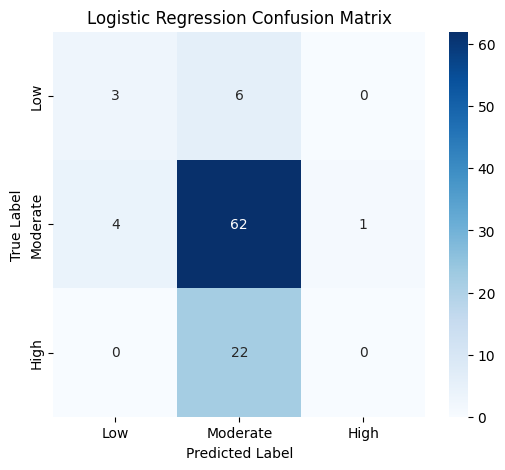

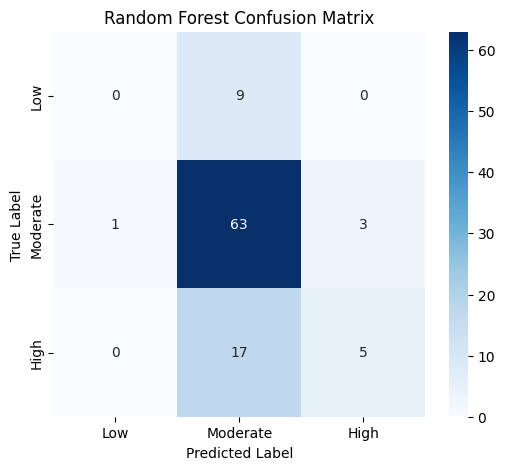

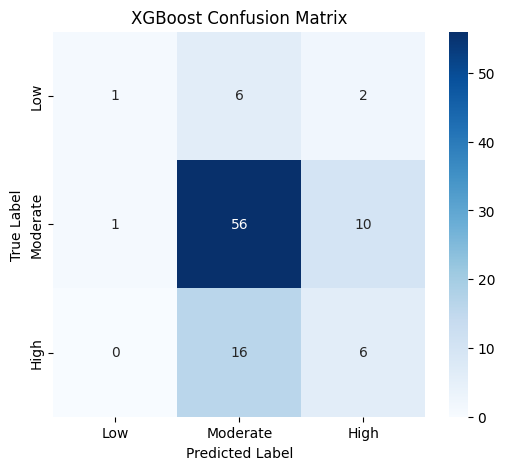

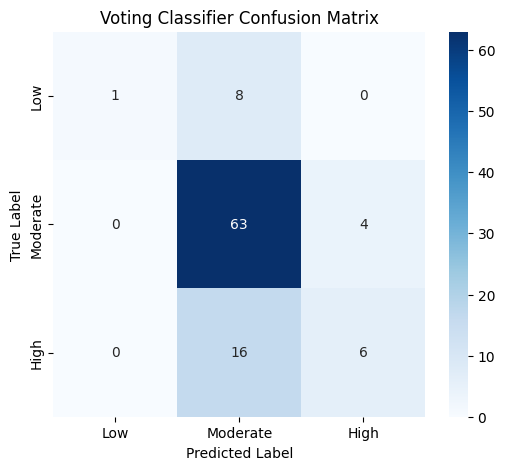

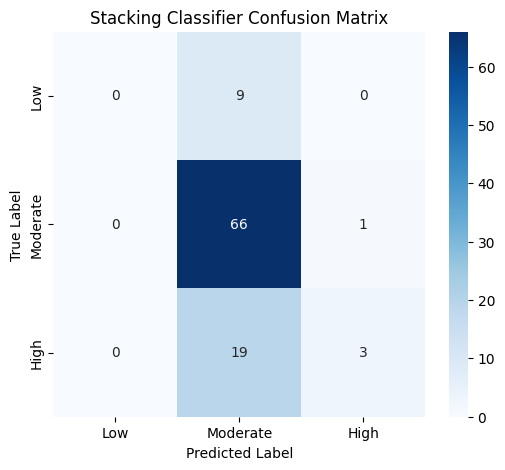

In [126]:
# Khai báo dictionary lưu confusion matrix

confusion_matrices = {}

# Tạo confusion matrix cho từng mô hình

for model_name, model in trained_models.items():

    # Dự đoán trên validation set

    validation_prediction = model.predict(
        X_validation
    )

    # Tính confusion matrix

    matrix = confusion_matrix(
        y_validation,
        validation_prediction
    )


    # Lưu kết quả

    confusion_matrices[model_name] = matrix

    # Hiển thị confusion matrix

    plt.figure(
        figsize=(6, 5)
    )

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "Low",
            "Moderate",
            "High"
        ],
        yticklabels=[
            "Low",
            "Moderate",
            "High"
        ]
    )

    plt.title(
        f"{model_name} Confusion Matrix"
    )

    plt.xlabel(
        "Predicted Label"
    )

    plt.ylabel(
        "True Label"
    )

    plt.show()

## 3.3 ROC Curve Analysis

Đánh giá khả năng phân biệt giữa các nhóm Digital Burnout Level của các mô hình Machine Learning thông qua chỉ số ROC-AUC.

ROC Curve biểu diễn mối quan hệ giữa:

- True Positive Rate (Recall).
- False Positive Rate.

Đối với bài toán phân loại đa lớp Digital Burnout, phương pháp One-vs-Rest (OvR) được sử dụng để đánh giá khả năng phân biệt từng lớp so với các lớp còn lại.

ROC-AUC được sử dụng như một chỉ số bổ sung nhằm đánh giá khả năng phân biệt của mô hình, đặc biệt trong bối cảnh dữ liệu có sự mất cân bằng giữa các lớp.

In [128]:
# Lưu kết quả ROC-AUC

roc_results = {}

plt.figure(
    figsize=(8,6)
)

for model_name, model in trained_models.items():

    # Lấy xác suất dự đoán

    y_probability = model.predict_proba(
        X_validation
    )

    # Tính macro ROC-AUC

    roc_auc = roc_auc_score(
        y_validation,
        y_probability,
        multi_class="ovr",
        average="macro"
    )

    roc_results[model_name] = roc_auc

    print(
        f"{model_name}: {roc_auc:.4f}"
    )

Logistic Regression: 0.6488
Random Forest: 0.7361
XGBoost: 0.6984
Voting Classifier: 0.7261
Stacking Classifier: 0.6869


<Figure size 800x600 with 0 Axes>

In [129]:
roc_table = pd.DataFrame(
    roc_results.items(),
    columns=[
        "Model",
        "ROC-AUC"
    ]
)

roc_table = roc_table.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(
    roc_table
)

,Model,ROC-AUC
0,Random Forest,0.736139
1,Voting Classifier,0.726095
2,XGBoost,0.698392
3,Stacking Classifier,0.686886
4,Logistic Regression,0.648771


## 3.4 Best Model Selection

Lựa chọn mô hình tối ưu dựa trên nhiều tiêu chí đánh giá thay vì chỉ sử dụng Accuracy.

Do dataset Digital Burnout có sự mất cân bằng giữa các lớp, mô hình được lựa chọn dựa trên ba tiêu chí:

- ROC-AUC: đánh giá khả năng phân biệt giữa các nhóm burnout.
- Macro Recall: đánh giá khả năng nhận diện đồng đều giữa các lớp.
- Macro F1-score: cân bằng giữa Precision và Recall.

Công thức lựa chọn:

Selection Score = 0.40 × ROC-AUC + 0.35 × Macro Recall + 0.25 × Macro F1-score

Mô hình có Selection Score cao nhất được lựa chọn làm mô hình cuối cùng.

In [130]:
# Merge performance table và ROC result

selection_table = performance_table.merge(
    roc_table,
    on="Model"
)


# Tính Selection Score

selection_table["Selection Score"] = (
    0.40 * selection_table["ROC-AUC"]
    +
    0.35 * selection_table["Macro Recall"]
    +
    0.25 * selection_table["Macro F1-score"]
)


# Sắp xếp

selection_table = selection_table.sort_values(
    by="Selection Score",
    ascending=False
).reset_index(drop=True)

display(
    selection_table
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-score,Weighted F1-score,ROC-AUC,Selection Score
0,Voting Classifier,0.714286,0.774713,0.441379,0.464394,0.661920,0.726095,0.561019
1,XGBoost,0.642857,0.517094,0.406553,0.418077,0.612123,0.698392,0.526170
2,Random Forest,0.693878,0.444288,0.389190,0.380342,0.627028,0.736139,0.525758
3,Logistic Regression,0.663265,0.372487,0.419569,0.388270,0.574410,0.648771,0.503425
4,Stacking Classifier,0.704082,0.484043,0.373813,0.350215,0.612333,0.686886,0.493143


# 4. Export Results

Lưu trữ các kết quả huấn luyện, đánh giá và mô hình Machine Learning tốt nhất nhằm phục vụ cho các bước triển khai, tái sử dụng mô hình và phân tích tiếp theo.

Section này thực hiện:

- Lưu mô hình Machine Learning tốt nhất được lựa chọn từ bước Best Model Selection.
- Lưu toàn bộ các mô hình đã huấn luyện để phục vụ so sánh và tái sử dụng.
- Lưu bảng kết quả đánh giá mô hình.
- Lưu Confusion Matrix và Classification Report.
- Lưu Validation Dataset để kiểm tra lại mô hình trong tương lai.

## 4.1 Save Best Model

Lưu mô hình có hiệu suất tốt nhất dựa trên Selection Score để sử dụng làm mô hình dự đoán Digital Burnout Level cuối cùng.

Trong bước Best Model Selection, Voting Classifier đạt Selection Score cao nhất và được lựa chọn làm mô hình cuối cùng.

In [132]:
# Đường dẫn tương đối lưu model
model_output_path = "../../models/vietnam_dataset"

# Tạo folder nếu chưa tồn tại

os.makedirs(
    model_output_path,
    exist_ok=True
)

print(
    f"Model output directory: {model_output_path}"
)

Model output directory: ../../models/vietnam_dataset


In [133]:
# Lấy tên mô hình có Selection Score cao nhất

best_model_name = selection_table.loc[
    0,
    "Model"
]

print(
    f"Best Model: {best_model_name}"
)

Best Model: Voting Classifier


In [134]:
# Mapping tên model với object đã train

model_mapping = {
    "Logistic Regression": logistic_regression_pipeline,
    "Random Forest": random_forest_pipeline,
    "XGBoost": xgboost_pipeline,
    "Voting Classifier": voting_classifier_pipeline,
    "Stacking Classifier": stacking_classifier_pipeline
}

# Lấy mô hình tốt nhất

best_model = model_mapping[
    best_model_name
]

In [135]:
# Lưu best model

joblib.dump(
    best_model,
    os.path.join(
        model_output_path,
        "best_model.joblib"
    )
)

print(
    "Đã lưu best model thành công."
)

Đã lưu best model thành công.


## 4.2 Save All Trained Models

Lưu trữ toàn bộ các mô hình Machine Learning đã được huấn luyện trong quá trình thử nghiệm nhằm phục vụ việc tái đánh giá, so sánh hiệu suất và sử dụng lại trong các bước triển khai tiếp theo.

Các mô hình được lưu bao gồm:

- Logistic Regression.
- Random Forest.
- XGBoost.
- Voting Classifier.
- Stacking Classifier.

Việc lưu toàn bộ mô hình giúp đảm bảo khả năng truy xuất lại các kết quả thực nghiệm trong quá trình nghiên cứu.

In [136]:
# Danh sách model cần lưu

model_files = {

    "Logistic Regression": "logistic_regression.joblib",
    "Random Forest": "random_forest.joblib",
    "XGBoost": "xgboost.joblib",
    "Voting Classifier": "voting_classifier.joblib",
    "Stacking Classifier": "stacking_classifier.joblib"

}

In [137]:
# Lưu từng mô hình

for model_name, file_name in model_files.items():

    joblib.dump(
        model_mapping[model_name],
        os.path.join(
            model_output_path,
            file_name
        )
    )

print(
    "Đã lưu toàn bộ mô hình thành công."
)

Đã lưu toàn bộ mô hình thành công.


In [138]:
# Kiểm tra các model đã được lưu

saved_model_files = []

for file_name in model_files.values():

    file_path = os.path.join(
        model_output_path,
        file_name
    )

    saved_model_files.append({
        "File Name": file_name,
        "Saved": os.path.exists(file_path)
    })

saved_model_table = pd.DataFrame(
    saved_model_files
)

display(
    saved_model_table
)

,File Name,Saved
0,logistic_regression.joblib,True
1,random_forest.joblib,True
2,xgboost.joblib,True
3,voting_classifier.joblib,True
4,stacking_classifier.joblib,True


## 4.3 Save Evaluation Results

Lưu trữ toàn bộ kết quả đánh giá mô hình sau quá trình huấn luyện nhằm phục vụ việc phân tích, báo cáo và tái kiểm tra hiệu suất mô hình.

Các kết quả được lưu bao gồm:

- Bảng so sánh hiệu suất của các mô hình.
- Confusion Matrix của từng mô hình.
- Classification Report của từng mô hình.
- Validation Dataset sử dụng trong quá trình đánh giá.

Việc lưu trữ các kết quả này giúp đảm bảo khả năng truy xuất lại toàn bộ quá trình đánh giá mô hình trong nghiên cứu.

In [139]:
# Lưu bảng hiệu suất mô hình

performance_table.to_csv(
    os.path.join(
        model_output_path,
        "model_performance.csv"
    ),
    index=False
)

print(
    "Đã lưu model performance."
)

Đã lưu model performance.


In [140]:
# Lưu confusion matrices

joblib.dump(
    confusion_matrices,
    os.path.join(
        model_output_path,
        "confusion_matrices.joblib"
    )
)

print(
    "Đã lưu confusion matrices."
)

Đã lưu confusion matrices.


In [141]:
# Khởi tạo dictionary lưu classification report

classification_reports = {}

# Tạo classification report cho từng model

for model_name, model in trained_models.items():

    validation_prediction = model.predict(
        X_validation
    )

    report = classification_report(
        y_validation,
        validation_prediction,
        target_names=[
            "Low",
            "Moderate",
            "High"
        ],
        output_dict=True,
        zero_division=0
    )

    classification_reports[model_name] = report

# Lưu classification reports

joblib.dump(
    classification_reports,
    os.path.join(
        model_output_path,
        "classification_reports.joblib"
    )
)

print(
    "Đã lưu classification reports."
)

Đã lưu classification reports.


In [142]:
# Lưu X validation

joblib.dump(
    X_validation,
    os.path.join(
        model_output_path,
        "X_validation.joblib"
    )
)


# Lưu y validation

joblib.dump(
    y_validation,
    os.path.join(
        model_output_path,
        "y_validation.joblib"
    )
)

print(
    "Đã lưu validation dataset."
)

Đã lưu validation dataset.


In [143]:
# Kiểm tra toàn bộ file output

exported_files = os.listdir(
    model_output_path
)

export_table = pd.DataFrame(
    {
        "Exported Files": exported_files
    }
)

display(
    export_table
)

,Exported Files
0,best_model.joblib
1,classification_reports.joblib
2,confusion_matrices.joblib
3,logistic_regression.joblib
4,model_performance.csv
5,random_forest.joblib
6,stacking_classifier.joblib
7,voting_classifier.joblib
8,xgboost.joblib
9,X_validation.joblib
